## Nome: Cauã Campos de Souza e Silva
## Matricula: 651

---

## **Atividade 5** - Localização e Refinamento de Raízes

## Funções Auxiliares

In [1]:
# Plotar gráficos
import seaborn as sns
import matplotlib.pyplot as plt

# Analise de dados
import numpy as np
import pandas as pd

### Função e Derivada da Função

In [2]:
def target_function(x):
    return x**3 - 2*x**2 - 3*x + 1

def derivative_function(x):
    return 3*x**2 - 4*x - 3

intervalo = [-5, 5]

### Método de Newton-Raphson

In [3]:
# implementa o processo de iteração usando a fórmula de Newton-Raphson
def newton_raphson_method(initial_guess, tolerance, max_iterations):
    """
    Aplica o método de Newton–Raphson para aproximar uma raiz de target_function(x).

    :param initial_guess: chute inicial x0
    :param tolerance: tolerância para parada (critério |f(x)| < tolerance)
    :param max_iterations: número máximo de iterações
    :return: raiz aproximada (float), número de iterações (int)
    """
    x_n = initial_guess
    for iteration in range(max_iterations):
        f_x = target_function(x_n)
        f_prime_x = derivative_function(x_n)

        # Evitar divisão por zero
        if f_prime_x == 0:
            print("A derivada é zero. Não é possível prosseguir.")
            return x_n, iteration + 1 # Retornar a aproximação atual e a contagem de iterações

        # Verificar convergência com base na tolerância
        if abs(f_x) < tolerance:
            return x_n, iteration + 1 # Retornar a raiz e a contagem de iterações

        x_n = x_n - f_x / f_prime_x

    # Se o número máximo de iterações for atingido sem convergência
    print("Número máximo de iterações atingido sem alcançar a tolerância desejada.")
    return x_n, max_iterations

---

## Parte Prática
No Inatel, os alunos de engenharia muitas vezes precisam analisar funções matemáticas para resolver problemas práticos, como verificar o comportamento de circuitos, sinais ou sistemas de controle. Encontrar as raízes de uma função é um passo importante nesses contextos, pois pode indicar pontos de equilíbrio, frequências de ressonância ou condições de operação de um sistema.

Seja a função
$f(x) = x^3 – 2x^2 – 3x + 1$.

Sabendo que esta função possui raízes no intervalo [−5,5], utilize o TEU com espaçamento de 1 para localizar os intervalos que contêm cada uma das raízes reais da função.

In [4]:
df = pd.DataFrame(columns=["x", "f(x)", "f1(x)"])
for x in range(intervalo[0], intervalo[1]+1):
    df = pd.concat([df, pd.DataFrame({"x": [x], "f(x)": [target_function(x)], "f1(x)": [derivative_function(x)]})]).reset_index(drop=True)

print(df.to_string(index=False))

 x f(x) f1(x)
-5 -159    92
-4  -83    61
-3  -35    36
-2   -9    17
-1    1     4
 0    1    -3
 1   -3    -4
 2   -5     1
 3    1    12
 4   21    29
 5   61    52


1. Utilizando o Teorema do Valor Intermediário (TEU) e espaçamento unitário no intervalo [−5,5], determine os subintervalos que contêm cada uma das raízes reais da função.

In [8]:
def mudou_sinal(fa, fb):
    # TEU: existe raiz em [a,b] se f é contínua e fa*fb < 0
    return fa * fb < 0

intervalos = []
chutes_iniciais = []
for x in range(df.shape[0]-1):
    # 1. Verificar se há mudança de sinal na função
    # 2. Escolher os chutes iniciais para Newton-Raphson (utilize o ponto médio do intervalo)
    fa = df.loc[x, "f(x)"]
    fb = df.loc[x + 1, "f(x)"]

    # testando se muudou o sinal
    if mudou_sinal(fa, fb):
        a = df.loc[x, "x"]
        b = df.loc[x + 1, "x"]

        intervalos.append((a, b))

        # chute inicial = meio do intervalo (padrão safe)
        chute = (a + b) / 2
        chutes_iniciais.append(chute)

print("Intervalos com raiz:", intervalos)
print("Chutes iniciais:", chutes_iniciais)

Intervalos com raiz: [(-2, -1), (0, 1), (2, 3)]
Chutes iniciais: [-1.5, 0.5, 2.5]


2. Identifique visualmente os pontos onde a curva cruza o eixo x e compare com os intervalos obtidos pelo TEU.

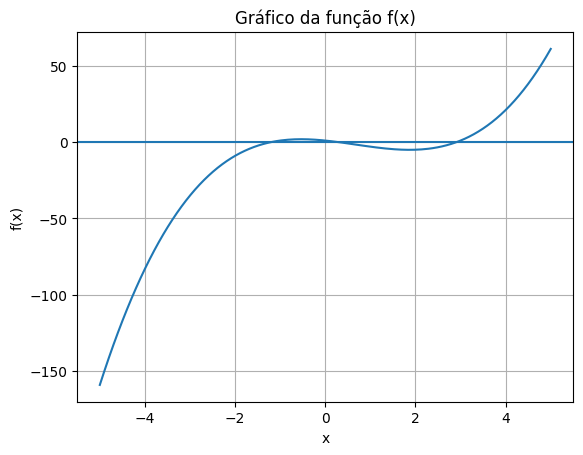

In [9]:
# Plote um gráfico de linhas que mostre a função.
# criando os pontos
x_vals = np.linspace(-5, 5, 200)

# jogando na função
y_vals = target_function(x_vals)

plt.figure()

# linha do zero (eixo x), ajuda a ver onde cruza
plt.axhline(0)

# plot padrão
plt.plot(x_vals, y_vals)

plt.title("Gráfico da função f(x)")
plt.xlabel("x")
plt.ylabel("f(x)")

# grade
plt.grid()

plt.show()

3. Implemente o Método de Newton-Raphson nos pontos iniciais obtidos.

In [10]:
tolerancia = 1e-9
iteracao_max = 250

# Implementação do método consta nas funções auxiliares
raizes_nr = []

for chute in chutes_iniciais:
    # joga o chute inicial no método
    raiz, it = newton_raphson_method(chute, tolerancia, iteracao_max)

    raizes_nr.append((raiz, it))

print("Raízes pelo Newton-Raphson:")
for r in raizes_nr:
    print(f"Raiz: {r[0]:.6f} | Iterações: {r[1]}")

Raízes pelo Newton-Raphson:
Raiz: -1.198691 | Iterações: 5
Raiz: 0.286462 | Iterações: 4
Raiz: 2.912229 | Iterações: 6


4. Implemente o Método de Bissecção

In [11]:
def bisseccao(a, b, tol=1e-9, max_iter=100):
    # primeira checagem básica
    if target_function(a) * target_function(b) > 0:
        print("Intervalo inválido! Não tem raiz garantida aqui.")
        return None

    for i in range(max_iter):
        # pega o meio do intervalo
        c = (a + b) / 2
        fc = target_function(c)

        # se já tá bom o suficiente, para
        if abs(fc) < tol:
            return c, i+1

        # decide pra qual lado vai continuar
        if target_function(a) * fc < 0:
            b = c  # raiz tá na esquerda
        else:
            a = c  # raiz tá na direita

    # se chegou aqui, parou por causa do limite
    return c, max_iter


raizes_bis = []

for intervalo in intervalos:
    a, b = intervalo

    raiz, it = bisseccao(a, b)
    raizes_bis.append((raiz, it))

print("Raízes pela Bissecção:")
for r in raizes_bis:
    print(f"Raiz: {r[0]:.6f} | Iterações: {r[1]}")

Raízes pela Bissecção:
Raiz: -1.198691 | Iterações: 32
Raiz: 0.286462 | Iterações: 28
Raiz: 2.912229 | Iterações: 29


---
## Parte Teórica

1. Quais são as limitações do uso do TEU para encontrar raízes de funções?

Resposta: O TEU é meio “cego”, ele só garante que existe uma raiz quando rola troca de sinal. Ele não diz quantas raízes tem no intervalo nem onde exatamente elas estão.
E se a função encostar no zero sem trocar sinal (tipo raiz dupla), ele nem percebe.

2. Qual é a principal vantagem do método da bissecção em relação a outros métodos numéricos?

Resposta: A bissecção é tipo aquele método simples, lento, mas confiável.
Se tiver troca de sinal, ela VAI achar a raiz, pode demorar, mas chega lá.

3. Em quais situações o método de Newton-Raphson pode falhar ou não convergir?

Resposta:

- Se a derivada for zero
- Se o chute inicial for ruim

E em alguns casos pode até convergir pra raiz errada.